<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/Galaxy_clean_up_and_new_CMD_10012026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation (execute only if running on a cloud platform!)¶

In [1]:
# -- Use the following line for google colab removing the hash at the beginning.
! pip install -q 'corner==2.2.2' 'bilby==2.2.2' 'astropy==6.0.1'

## Initialization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import corner

In [3]:
!pip install healpy astropy pyvo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.1 MB/s eta 0:00:00


In [4]:
# REQUIREMENTS (already used in notebook):
# !pip install pyvo astropy healpy pandas

import json, numpy as np, pandas as pd, healpy as hp
from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u

# ---------- Config ----------
TAP_URL = "https://datalab.noirlab.edu/tap"
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90
SQL_FATAL_QUALITY = True          # keep True to avoid multi-million row downloads
MAG_MIN, MAG_MAX = 16.0, 24.5     # light magnitude guard for tractability
NSIDE_FORCE = None                # set to an int to override skymap NSIDE if needed (usually None)
NEST_FORCE  = None                # set to True/False to override, else read from skymap

Z_MIN, Z_MAX = 0.043, 0.061       # from GW distance ~ 200–280 Mpc

from pyvo import dal as vo

svc = vo.TAPService(TAP_URL)

# ---------- Helpers ----------
def hpd_threshold(prob, level):
    flat = prob.ravel()
    order = np.argsort(flat)[::-1]
    csum = np.cumsum(flat[order])
    return flat[order[np.searchsorted(csum, level * flat.sum())]]

def healpix_components(mask, nside, nest=True):
    npix = mask.size
    visited = np.zeros(npix, bool)
    comps = []
    idxs = np.where(mask)[0]
    idxset = set(idxs.tolist())
    for s in idxs:
        if visited[s]: continue
        q=[int(s)]; visited[s]=True; comp=[int(s)]
        while q:
            p=q.pop()
            neigh = hp.get_all_neighbours(nside, p, nest=nest)
            for nb in neigh[neigh>=0]:
                if (nb in idxset) and (not visited[nb]):
                    visited[nb]=True; q.append(int(nb)); comp.append(int(nb))
        comps.append(comp)
    return comps

def minimal_ra_span(ra_deg):
    ra = np.mod(ra_deg, 360.0)
    s = np.sort(ra); dbl = np.concatenate([s, s+360])
    N=len(s); best=(1e9,0,0)
    for i in range(N):
        j=i+N-1
        w=dbl[j]-dbl[i]
        if w<best[0]:
            a=(dbl[i])%360.0; b=(a+w)%360.0; best=(w,a,b)
    return best[1], best[2]

# ---------- 1) Load skymap & build 90% main island ----------
with fits.open(SKYMAP_URL, memmap=True) as h:
    tab = h[1].data; hdr = h[1].header
    prob      = np.asarray(tab["PROB"], float)
    distmu    = np.asarray(tab["DISTMU"], float)
    distsigma = np.asarray(tab["DISTSIGMA"], float)
    nside = int(hdr["NSIDE"]) if NSIDE_FORCE is None else int(NSIDE_FORCE)
    nest  = hdr.get("ORDERING","NESTED").upper().startswith("NEST") if NEST_FORCE is None else bool(NEST_FORCE)

thr  = hpd_threshold(prob, CREDIBLE)
mask = prob >= thr
comps = healpix_components(mask, nside, nest=nest)
main  = np.array(comps[np.argmax([prob[c].sum() for c in comps])], dtype=int)

theta, phi = hp.pix2ang(nside, main, nest=nest)
dec_deg = 90.0 - np.degrees(theta)
ra_deg  = np.degrees(phi) % 360.0
dec_min, dec_max = float(dec_deg.min()), float(dec_deg.max())
ra_min, ra_max   = minimal_ra_span(ra_deg)

funnel = {}

# ---------- 2) SQL rectangle query (DES main ⨝ y6_gold), fatal-only limits ----------
# We *do not* apply morphology or photo-z in SQL to preserve the funnel order.
where_sky = f"""
(g.ra BETWEEN {ra_min} AND {ra_max}) AND
(g.dec BETWEEN {dec_min} AND {dec_max})
"""

where_quality = "1=1"
if SQL_FATAL_QUALITY:
    where_quality = f"(g.flags_i < 4) AND (g.mag_auto_i BETWEEN {MAG_MIN} AND {MAG_MAX})"

adql = f"""
SELECT
  g.coadd_object_id AS coadd_object_id,
  g.ra, g.dec,
  g.mag_auto_i, g.flags_i,
  y.dnf_z,
  y.wavg_spread_model_z, y.wavg_spreaderr_model_z,
  y.spread_model_z,      y.spreaderr_model_z
FROM des_dr2.main AS g
JOIN des_dr2.y6_gold AS y
  ON g.coadd_object_id = y.coadd_object_id
WHERE
  {where_sky}
  AND {where_quality}
"""

rect_tbl = svc.search(adql).to_table()
funnel["step1_rectangle_sql"] = int(len(rect_tbl))

print(f"[1] Rectangle (SQL) — rows: {funnel['step1_rectangle_sql']}  "
      f"[flags_i<4={SQL_FATAL_QUALITY}, mag {MAG_MIN}–{MAG_MAX}]")

# ---------- 3) Exact 90% main-island mask ----------
theta = np.radians(90.0 - np.array(rect_tbl["dec"]))
phi   = np.radians(np.array(rect_tbl["ra"]) % 360.0)
pix   = hp.ang2pix(nside, theta, phi, nest=nest)
in_island = np.isin(pix, main)
island_tbl = rect_tbl[in_island]
funnel["step2_inside_island"] = int(len(island_tbl))
print(f"[2] Inside exact 90% main island — rows: {funnel['step2_inside_island']}")

# ---------- 4) Morphology (galaxy-like) ----------
wok = (island_tbl["wavg_spread_model_z"] > -98) & (island_tbl["wavg_spreaderr_model_z"] > -98)
m3  = np.where(
    wok,
    island_tbl["wavg_spread_model_z"] + 3*island_tbl["wavg_spreaderr_model_z"],
    island_tbl["spread_model_z"]      + 3*island_tbl["spreaderr_model_z"]
)
gal_mask = m3 > 0.005
gal_tbl  = island_tbl[gal_mask]
funnel["step3_morph_galaxies"] = int(len(gal_tbl))
print(f"[3] Morphology (extended) — rows: {funnel['step3_morph_galaxies']}")

# ---------- 5) Photo-z window (distance slice) ----------
z_ok = (gal_tbl["dnf_z"] >= Z_MIN) & (gal_tbl["dnf_z"] <= Z_MAX)
final_tbl = gal_tbl[z_ok]
funnel["step4_photoz_window"] = int(len(final_tbl))
print(f"[4] Photo-z in [{Z_MIN},{Z_MAX}] — rows: {funnel['step4_photoz_window']}")

# ---------- Save artifacts ----------
# CSV + FITS of final candidates
final_df = final_tbl.to_pandas()
final_df.to_csv("GW190814_candidates_90pct.csv", index=False)
final_tbl.write("GW190814_candidates_90pct.fits", overwrite=True)

# Counts JSON + metadata
meta = {
    "event": "GW190814",
    "credible_level": CREDIBLE,
    "main_island_prob_mass": float(prob[main].sum()),
    "nside": nside, "nest": nest,
    "ra_min_deg": ra_min, "ra_max_deg": ra_max,
    "dec_min_deg": dec_min, "dec_max_deg": dec_max,
    "sql_fatal_quality": SQL_FATAL_QUALITY,
    "mag_range_i": [MAG_MIN, MAG_MAX],
    "z_window": [Z_MIN, Z_MAX]
}
out = {"counts": funnel, "meta": meta}
with open("GW190814_funnel_counts.json", "w") as f:
    json.dump(out, f, indent=2)

print("\nSaved:")
print(" - GW190814_candidates_90pct.csv")
print(" - GW190814_candidates_90pct.fits")
print(" - GW190814_funnel_counts.json")


[1] Rectangle (SQL) — rows: 2119644  [flags_i<4=True, mag 16.0–24.5]
[2] Inside exact 90% main island — rows: 1393743


[3] Morphology (extended) — rows: 1321738
[4] Photo-z in [0.043,0.061] — rows: 589

Saved:
 - GW190814_candidates_90pct.csv
 - GW190814_candidates_90pct.fits
 - GW190814_funnel_counts.json


In [5]:
# Crossmatch your 589 DES candidates to GLADE (GLADE+) via VizieR (robust)
# Outputs:
#  - GW190814_DES_vs_GLADE_matches_2arcsec.csv
#  - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv

# ---------- deps ----------
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["astroquery", "astropy", "pandas", "numpy"]:
    pip_install(p)

import pandas as pd, numpy as np
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.vizier import Vizier

# ---------- inputs ----------
des_csv = "/content/GW190814_candidates_90pct.csv"     # your 589-list
# 90% main-island rectangle (deg) – from your funnel run
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

margin_deg   = 0.15          # safety border around the box
match_radius = 2.0 * u.arcsec

# ---------- load DES candidates ----------
des_df = pd.read_csv(des_csv)
if not {"ra","dec"}.issubset({c.lower() for c in des_df.columns}):
    raise ValueError("Expected columns 'ra' and 'dec' in the CSV.")
des_tab = Table.from_pandas(des_df)

# ---------- find a GLADE catalog on this VizieR mirror ----------
cats = Vizier.find_catalogs("GLADE")
if not cats:
    raise RuntimeError("No GLADE entries found on this VizieR mirror.")
# Prefer the collection key containing 'VII/281' (GLADE+), else take any GLADE entry
preferred = [k for k in cats.keys() if "VII/281" in k]
cat_id = preferred[0] if preferred else list(cats.keys())[0]
print("Using catalog id:", cat_id)

# ---------- discover RA/Dec column names ----------
Vizier.ROW_LIMIT = 50
sample = None
try:
    sample = Vizier.get_catalogs(cat_id)[0]   # sometimes returns metadata table
except Exception:
    pass
# try a tiny region to get real columns if needed
if sample is None or len(sample.colnames) == 0:
    try:
        tiny = Vizier.query_region(SkyCoord(0*u.deg, 0*u.deg), width=0.1*u.deg, height=0.1*u.deg, catalog=cat_id)
        if len(tiny) > 0:
            sample = tiny[0]
    except Exception:
        pass

if sample is None:
    raise RuntimeError("Could not inspect columns for the chosen GLADE catalog.")

ra_candidates  = ["RAJ2000","RA_ICRS","_RAJ2000","raj2000","ra"]
dec_candidates = ["DEJ2000","DE_ICRS","_DEJ2000","dej2000","dec"]
cols_lower = {c.lower(): c for c in sample.colnames}

def pick_name(cands):
    for c in cands:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return None

glade_ra  = pick_name(ra_candidates)
glade_dec = pick_name(dec_candidates)
if glade_ra is None or glade_dec is None:
    raise RuntimeError(f"Could not find RA/Dec column names. Columns seen: {sample.colnames}")
print("GLADE RA/Dec columns:", glade_ra, glade_dec)

# ---------- region query for our rectangle (+ margin) ----------
Vizier.ROW_LIMIT = -1
Vizier.columns = [glade_ra, glade_dec, "Name", "z", "Dist", "DistErr"]

ra_c  = 0.5*(ra_min + ra_max)
dec_c = 0.5*(dec_min + dec_max)
width =  (ra_max - ra_min) + 2*margin_deg
height = (dec_max - dec_min) + 2*margin_deg
center = SkyCoord(ra=ra_c*u.deg, dec=dec_c*u.deg, frame="icrs")

res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat_id)
if len(res) == 0 or len(res[0]) == 0:
    # last-chance: expand box slightly more
    res = Vizier.query_region(center, width=(width+0.4)*u.deg, height=(height+0.4)*u.deg, catalog=cat_id)
if len(res) == 0 or len(res[0]) == 0:
    raise RuntimeError("VizieR returned no GLADE rows in this region after expansion.")

glade_tab = res[0]
print(f"GLADE rows retrieved in box: {len(glade_tab)}")

# ---------- robust SkyCoord creation for GLADE RA/Dec ----------
def make_glade_sky(tab, ra_name, dec_name):
    ra_col, dec_col = tab[ra_name], tab[dec_name]
    # try plain floats in degrees
    try:
        ra_deg  = np.array(ra_col, dtype=float)
        dec_deg = np.array(dec_col, dtype=float)
        return SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    except Exception:
        pass
    # try sexagesimal strings as degrees
    try:
        return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.deg, u.deg), frame="icrs")
    except Exception:
        pass
    # fall back to hourangle for RA, degrees for Dec
    return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.hourangle, u.deg), frame="icrs")

des_sky   = SkyCoord(ra=des_tab["ra"]*u.deg,       dec=des_tab["dec"]*u.deg,       frame="icrs")
glade_sky = make_glade_sky(glade_tab, glade_ra, glade_dec)

# ---------- local 2″ nearest-neighbour crossmatch ----------
idx, sep2d, _ = des_sky.match_to_catalog_sky(glade_sky)
matched_mask  = sep2d < match_radius

matched_des   = des_tab[matched_mask]
matched_glade = glade_tab[idx[matched_mask]]
matched       = hstack([matched_des, matched_glade])

unmatched = des_tab[~matched_mask]

# ---------- report & save ----------
n_total    = len(des_tab)
n_matched  = len(matched)
n_unmatched= len(unmatched)
pct        = round(100.0 * n_matched / n_total, 2)

print({
    "total_DES_candidates": n_total,
    "matched_in_GLADE": n_matched,
    "unmatched": n_unmatched,
    "completeness_percent": pct,
    "match_radius_arcsec": float(match_radius.to_value(u.arcsec)),
    "glade_rows_in_box": len(glade_tab),
    "catalog_id_used": cat_id,
    "glade_ra_col": glade_ra,
    "glade_dec_col": glade_dec
})

matched.to_pandas().to_csv("GW190814_DES_vs_GLADE_matches_2arcsec.csv", index=False)
unmatched.to_pandas().to_csv("GW190814_DES_candidates_not_in_GLADE_2arcsec.csv", index=False)
print("Saved:")
print(" - GW190814_DES_vs_GLADE_matches_2arcsec.csv")
print(" - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv")


Using catalog id: VII/281
GLADE RA/Dec columns: RAJ2000 DEJ2000
GLADE rows retrieved in box: 2739
{'total_DES_candidates': 589, 'matched_in_GLADE': 95, 'unmatched': 494, 'completeness_percent': 16.13, 'match_radius_arcsec': 2.0, 'glade_rows_in_box': 2739, 'catalog_id_used': 'VII/281', 'glade_ra_col': 'RAJ2000', 'glade_dec_col': 'DEJ2000'}
Saved:
 - GW190814_DES_vs_GLADE_matches_2arcsec.csv
 - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv


In [6]:
# DESI Legacy Imaging (DR10 preferred, else DR9) — robust RA/Dec match with brick_primary filter and safe SkyCoord

# deps
import sys, subprocess
def pip_install(pkg):
    try: __import__(pkg.split("==")[0].split(">=")[0])
    except Exception: subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
for p in ["pyvo", "astropy", "pandas", "numpy"]:
    pip_install(p)

import numpy as np, pandas as pd
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from pyvo import dal as vo

# ---- Inputs ----
TAP_URL = "https://datalab.noirlab.edu/tap"
des_csv = "/content/GW190814_candidates_90pct.csv"
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
match_radius = 1.5 * u.arcsec

# ---- Load DES list ----
des = Table.read(des_csv, format="ascii.csv")
if not {"ra","dec"}.issubset(set(des.colnames)):
    raise ValueError("CSV must have 'ra' and 'dec' columns.")
des_ra = des["ra"].astype(float)
des_dec = des["dec"].astype(float)
des_sky = SkyCoord(des_ra, des_dec, unit=("deg","deg"), frame="icrs")

svc = vo.TAPService(TAP_URL)

# ---- Discover Legacy tables ----
tables = svc.search("""
SELECT table_name
FROM TAP_SCHEMA.tables
WHERE LOWER(table_name) LIKE 'ls\_%'
""")
names = [str(r["table_name"]) for r in tables]
print("Found", len(names), "Legacy tables.")

# pick a tractor table
preferred = [
    "ls_dr10.tractor_primary", "ls_dr10.tractor", "ls_dr10.tractor_south",
    "ls_dr9.tractor_primary",  "ls_dr9.tractor",  "ls_dr9.tractor_south",
]
candidate = next((t for t in preferred if t in names), None)
if candidate is None:
    cand = [n for n in names if "tractor" in n.lower()]
    if not cand:
        raise RuntimeError("No Legacy Surveys tractor-like table on this TAP.")
    candidate = cand[0]
print("Using Legacy table:", candidate)

# ---- Column discovery ----
cols = svc.search(f"""
SELECT column_name
FROM TAP_SCHEMA.columns
WHERE table_name = '{candidate}'
""")
colnames = {str(r["column_name"]).lower(): str(r["column_name"]) for r in cols}
def pick(*opts):
    for o in opts:
        if o.lower() in colnames: return colnames[o.lower()]
    return None

ra_col  = pick("ra","RA")
dec_col = pick("dec","DEC")
bp_col  = pick("brick_primary","BRICK_PRIMARY")  # optional
print("Columns:", {"ra": ra_col, "dec": dec_col, "brick_primary": bp_col})

# ---- Build ADQL with brick_primary if present ----
where_bp = f"AND {bp_col}=1" if bp_col is not None else ""
adql = f"""
SELECT {ra_col} AS ra, {dec_col} AS dec
FROM {candidate}
WHERE {ra_col} BETWEEN {ra_min} AND {ra_max}
  AND {dec_col} BETWEEN {dec_min} AND {dec_max}
  {where_bp}
"""
res = svc.search(adql)
ls_tab = res.to_table()
print(f"Rows fetched from {candidate}: {len(ls_tab)}")

# ---- Coerce to clean float arrays; drop rows with bad RA/Dec ----
ls_df = ls_tab.to_pandas()
ls_df["ra"]  = pd.to_numeric(ls_df["ra"],  errors="coerce")
ls_df["dec"] = pd.to_numeric(ls_df["dec"], errors="coerce")
ls_df = ls_df.dropna(subset=["ra","dec"]).reset_index(drop=True)
print("Rows after numeric coercion:", len(ls_df))

# ---- Build SkyCoord safely (unit tuple) ----
ls_sky = SkyCoord(ls_df["ra"].to_numpy(), ls_df["dec"].to_numpy(), unit=("deg","deg"), frame="icrs")

# ---- Local 1.5″ match ----
idx, sep, _ = des_sky.match_to_catalog_sky(ls_sky)
mask = sep < match_radius

print({
    "catalog": f"Legacy {candidate}",
    "matched": int(mask.sum()),
    "unmatched": int(len(des)-mask.sum()),
    "percent": round(100*mask.mean(), 2)
})

# ---- Save CSVs ----
matched = hstack([des[mask], Table.from_pandas(ls_df.iloc[idx[mask]].reset_index(drop=True))])
unmatched = des[~mask]
matched.to_pandas().to_csv("GW190814_DES_vs_Legacy_1p5arcsec.csv", index=False)
unmatched.to_pandas().to_csv("GW190814_DES_not_in_Legacy_1p5arcsec.csv", index=False)
print("Saved:")
print(" - GW190814_DES_vs_Legacy_1p5arcsec.csv")
print(" - GW190814_DES_not_in_Legacy_1p5arcsec.csv")


<>:38: SyntaxWarning: invalid escape sequence '\_'
<>:38: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipython-input-3699435136.py:38: SyntaxWarning: invalid escape sequence '\_'
  WHERE LOWER(table_name) LIKE 'ls\_%'


Found 93 Legacy tables.
Using Legacy table: ls_dr10.tractor
Columns: {'ra': 'ra', 'dec': 'dec', 'brick_primary': 'brick_primary'}
Rows fetched from ls_dr10.tractor: 4319398
Rows after numeric coercion: 4319398
{'catalog': 'Legacy ls_dr10.tractor', 'matched': 512, 'unmatched': 77, 'percent': 86.93}
Saved:
 - GW190814_DES_vs_Legacy_1p5arcsec.csv
 - GW190814_DES_not_in_Legacy_1p5arcsec.csv


In [7]:
!pip -q install astroquery astropy pandas

import pandas as pd
import numpy as np
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u
import time

/tmp/ipython-input-1637533296.py:5: DeprecationWarning: the ``ned`` module has been moved to astroquery.ipac.ned, please update your imports.
  from astroquery.ned import Ned


In [8]:
des = pd.read_csv("GW190814_candidates_90pct.csv")
print("DES total:", len(des))

DES total: 589


In [9]:
kept = pd.read_csv("KEPT_OBJECTS_489.csv")  # ← change filename
print("Kept list length:", len(kept))
print(kept.columns.tolist())

Kept list length: 478
['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z']


In [10]:
des_489 = des[des["coadd_object_id"].isin(kept["coadd_object_id"])].copy()
print("DES after visual cleaning:", len(des_489))

DES after visual cleaning: 478


In [11]:
rows = []

for i, r in des_489.iterrows():
    coord = SkyCoord(r["ra"]*u.deg, r["dec"]*u.deg, frame="icrs")
    try:
        res = Ned.query_region(coord, radius=5*u.arcsec)

        # Keep only rows with redshift info
        if "Redshift" in res.colnames:
            res = res[~res["Redshift"].mask] if hasattr(res["Redshift"], "mask") else res

        if len(res) > 0:
            best = res[0]
            rows.append({
                "coadd_object_id": int(r["coadd_object_id"]),
                "z_ned": float(best["Redshift"]),
                "ned_name": str(best["Object Name"]),
                "ned_type": str(best["Type"]),
                "ned_sep_arcsec": float(best["Separation"]) * 60.0  # arcmin → arcsec
            })
        else:
            rows.append({
                "coadd_object_id": int(r["coadd_object_id"]),
                "z_ned": np.nan,
                "ned_name": None,
                "ned_type": None,
                "ned_sep_arcsec": np.nan
            })

    except Exception as e:
        rows.append({
            "coadd_object_id": int(r["coadd_object_id"]),
            "z_ned": np.nan,
            "ned_name": None,
            "ned_type": f"ERROR: {e}",
            "ned_sep_arcsec": np.nan
        })

    time.sleep(0.6)  # IMPORTANT: don’t hammer NED

In [12]:
ned_df = pd.DataFrame(rows)

des_489_ned = des_489.merge(ned_df, on="coadd_object_id", how="left")
des_489_ned["has_specz_ned"] = des_489_ned["z_ned"].notna()

print(des_489_ned["has_specz_ned"].value_counts())

has_specz_ned
False    413
True      65
Name: count, dtype: int64


In [13]:
des_489_ned.to_csv("GW190814_489_with_NED_specz.csv", index=False)
print("Saved GW190814_489_with_NED_specz.csv")

Saved GW190814_489_with_NED_specz.csv


In [14]:
!pip -q install astroquery astropy pandas numpy

import time
import numpy as np
import pandas as pd
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u

INFILE  = "KEPT_OBJECTS_489.csv"   # <-- change if your file has a different name
OUTFILE = "NED_bulk_improved.csv"

df = pd.read_csv(INFILE).copy()
need_cols = {"coadd_object_id","ra","dec"}
if not need_cols.issubset(df.columns):
    raise ValueError(f"{INFILE} must contain columns {need_cols}. Found: {df.columns.tolist()}")

def ned_best_redshift(coord, radii_arcsec=(5,10)):
    """
    Returns best NED match that has a redshift.
    Tries radii in order; returns (z, name, type, sep_arcsec, radius_used) or None.
    """
    for rad in radii_arcsec:
        res = Ned.query_region(coord, radius=rad*u.arcsec)

        # If table has Redshift, keep only rows with a redshift
        if "Redshift" in res.colnames:
            # mask-aware filtering
            if hasattr(res["Redshift"], "mask"):
                res = res[~res["Redshift"].mask]
            else:
                res = res[res["Redshift"] == res["Redshift"]]  # drop NaN

        if len(res) == 0:
            continue

        # Convert separation to arcsec; choose closest
        # NED returns Separation in arcmin
        sep_arcsec = np.array(res["Separation"], dtype=float) * 60.0
        j = int(np.argmin(sep_arcsec))
        best = res[j]

        return (float(best["Redshift"]),
                str(best["Object Name"]),
                str(best["Type"]),
                float(sep_arcsec[j]),
                rad)
    return None

rows = []
n = len(df)

for k, r in enumerate(df.itertuples(index=False), start=1):
    coord = SkyCoord(r.ra*u.deg, r.dec*u.deg, frame="icrs")
    try:
        out = ned_best_redshift(coord, radii_arcsec=(5,10))
        if out is None:
            rows.append({
                "coadd_object_id": int(r.coadd_object_id),
                "z_ned": np.nan,
                "ned_name": None,
                "ned_type": None,
                "ned_sep_arcsec": np.nan,
                "ned_radius_used_arcsec": np.nan
            })
        else:
            z, name, typ, sep_as, rad_used = out
            rows.append({
                "coadd_object_id": int(r.coadd_object_id),
                "z_ned": z,
                "ned_name": name,
                "ned_type": typ,
                "ned_sep_arcsec": sep_as,
                "ned_radius_used_arcsec": rad_used
            })
    except Exception as e:
        rows.append({
            "coadd_object_id": int(r.coadd_object_id),
            "z_ned": np.nan,
            "ned_name": None,
            "ned_type": f"ERROR: {e}",
            "ned_sep_arcsec": np.nan,
            "ned_radius_used_arcsec": np.nan
        })

    # progress + rate limiting
    if k % 25 == 0:
        got = sum(1 for rr in rows if rr["z_ned"] == rr["z_ned"])  # not NaN
        print(f"NED progress: {k}/{n} (z found so far: {got})")
    time.sleep(0.6)  # be kind to NED

ned_df = pd.DataFrame(rows)
ned_df.to_csv(OUTFILE, index=False)
print("Saved:", OUTFILE)
print("NED redshifts found:", int(ned_df["z_ned"].notna().sum()), "out of", len(ned_df))

NED progress: 25/478 (z found so far: 12)
NED progress: 50/478 (z found so far: 19)
NED progress: 75/478 (z found so far: 25)
NED progress: 100/478 (z found so far: 31)
NED progress: 125/478 (z found so far: 38)
NED progress: 150/478 (z found so far: 43)
NED progress: 175/478 (z found so far: 51)
NED progress: 200/478 (z found so far: 53)
NED progress: 225/478 (z found so far: 58)
NED progress: 250/478 (z found so far: 61)
NED progress: 275/478 (z found so far: 61)
NED progress: 300/478 (z found so far: 61)
NED progress: 325/478 (z found so far: 61)
NED progress: 350/478 (z found so far: 61)
NED progress: 375/478 (z found so far: 61)
NED progress: 400/478 (z found so far: 62)
NED progress: 425/478 (z found so far: 62)
NED progress: 450/478 (z found so far: 64)
NED progress: 475/478 (z found so far: 65)
Saved: NED_bulk_improved.csv
NED redshifts found: 65 out of 478


In [15]:
import pandas as pd
import numpy as np

BASE_FILE = "KEPT_OBJECTS_489.csv"
NED_FILE  = "NED_bulk_improved.csv"
OUT_FILE  = "KEPT_OBJECTS_489_with_specz.csv"

base = pd.read_csv(BASE_FILE)
ned  = pd.read_csv(NED_FILE)

# Keep only the useful NED columns
ned_cols = ["coadd_object_id", "z_ned", "ned_name", "ned_type", "ned_sep_arcsec", "ned_radius_used_arcsec"]
ned = ned[[c for c in ned_cols if c in ned.columns]].copy()

# Merge
m = base.merge(ned, on="coadd_object_id", how="left")

# Create unified spec-z columns (NED only)
m["z_spec"] = m["z_ned"]
m["z_spec_source"] = np.where(m["z_spec"].notna(), "NED", None)
m["has_specz"] = m["z_spec"].notna()

print("Rows:", len(m))
print("Spec-z found:", int(m["has_specz"].sum()))

m.to_csv(OUT_FILE, index=False)
print("Saved:", OUT_FILE)


Rows: 478
Spec-z found: 65
Saved: KEPT_OBJECTS_489_with_specz.csv


In [16]:
if "dnf_z" in m.columns:
    m["z_best"] = m["z_spec"].fillna(m["dnf_z"])
    m.to_csv(OUT_FILE, index=False)
    print("Also added z_best (z_spec else dnf_z).")
else:
    print("No dnf_z in base file; z_best not created.")

Also added z_best (z_spec else dnf_z).


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("KEPT_OBJECTS_489_with_specz.csv")

# Keep only objects with spectroscopic redshifts
spec = df[df["has_specz"]].copy()

print("Total galaxies:", len(df))
print("Spec-z galaxies:", len(spec))

Total galaxies: 478
Spec-z galaxies: 65


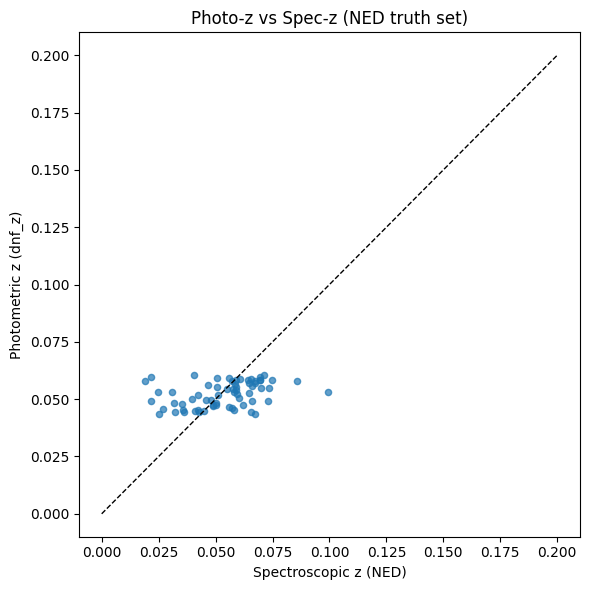

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(spec["z_ned"], spec["dnf_z"], s=20, alpha=0.7)
plt.plot([0, 0.2], [0, 0.2], color="black", linestyle="--", linewidth=1)
plt.xlabel("Spectroscopic z (NED)")
plt.ylabel("Photometric z (dnf_z)")
plt.title("Photo-z vs Spec-z (NED truth set)")
plt.tight_layout()
plt.show()

In [19]:
spec["dz"] = spec["dnf_z"] - spec["z_ned"]
spec["abs_dz"] = spec["dz"].abs()
spec["dz_over_1pz"] = spec["dz"] / (1 + spec["z_ned"])

print("Median |dnf_z − z_spec|:", spec["abs_dz"].median())
print("90th percentile |dnf_z − z_spec|:", spec["abs_dz"].quantile(0.90))
print("Median |dz|/(1+z):", spec["dz_over_1pz"].abs().median())

Median |dnf_z − z_spec|: 0.009583312999999996
90th percentile |dnf_z − z_spec|: 0.0238016038
Median |dz|/(1+z): 0.009157424213353797


In [20]:
bad_abs = spec[spec["abs_dz"] > 0.1]
bad_frac = spec[spec["dz_over_1pz"].abs() > 0.15]

print("Absolute outliers (|dz| > 0.1):", len(bad_abs))
print("Fractional outliers (|dz|/(1+z) > 0.15):", len(bad_frac))

bad_abs[["coadd_object_id","dnf_z","z_ned","abs_dz"]].head()

Absolute outliers (|dz| > 0.1): 0
Fractional outliers (|dz|/(1+z) > 0.15): 0


,coadd_object_id,dnf_z,z_ned,abs_dz


In [21]:
implausible = spec[(spec["z_ned"] < 0) | (spec["z_ned"] > 0.3)]

print("Implausible spec-z for GW190814:", len(implausible))
implausible[["coadd_object_id","z_ned","dnf_z","ned_name"]]

Implausible spec-z for GW190814: 0


,coadd_object_id,z_ned,dnf_z,ned_name


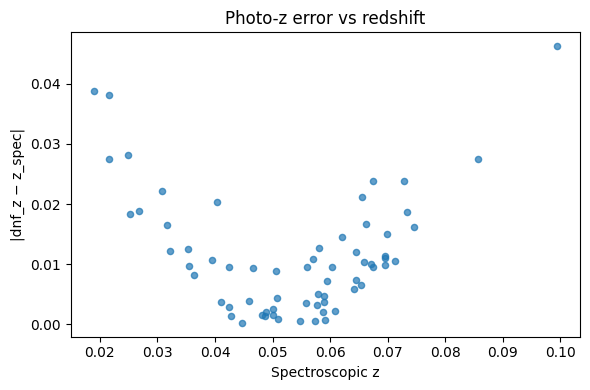

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(spec["z_ned"], spec["abs_dz"], s=20, alpha=0.7)
plt.xlabel("Spectroscopic z")
plt.ylabel("|dnf_z − z_spec|")
plt.title("Photo-z error vs redshift")
plt.tight_layout()
plt.show()

In [23]:
!pip -q install pyvo astropy pandas numpy

import numpy as np
import pandas as pd
import pyvo as vo
from astropy.coordinates import SkyCoord
import astropy.units as u

In [24]:
GAL_FILE = "KEPT_OBJECTS_489.csv"

gal = pd.read_csv(GAL_FILE)
print("Galaxy rows:", len(gal))
gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

Galaxy rows: 478


In [25]:
svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

adql = f"""
SELECT ra, dec,
       parallax, parallax_error,
       pmra, pmra_error,
       pmdec, pmdec_error,
       phot_g_mean_mag
FROM gaia_dr3.gaia_source
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
"""

print("Querying Gaia DR3 in patch (this can take a bit)...")
gaia = svc.search(adql).to_table().to_pandas()
print("Gaia rows in patch:", len(gaia))
gaia.head()

Querying Gaia DR3 in patch (this can take a bit)...
Gaia rows in patch: 77571


,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag
0,10.245251,-27.320145,4.503970,0.308881,9.320916,0.320317,22.777187,0.316370,19.219776
1,10.270006,-27.320741,0.056168,0.345809,-0.920814,0.363394,0.091194,0.350420,19.437714
2,10.266228,-27.306785,1.075754,0.050738,8.471269,0.046750,-13.789134,0.050629,15.786174
3,10.277242,-27.312775,0.465892,0.118876,1.416645,0.115652,-1.121080,0.113955,17.689524
4,10.268980,-27.304443,NaN,NaN,NaN,NaN,NaN,NaN,21.600849


In [26]:
gaia = gaia.dropna(subset=["ra","dec"]).copy()
gaia_sky = SkyCoord(gaia["ra"].values*u.deg, gaia["dec"].values*u.deg, frame="icrs")

idx, sep2d, _ = gal_sky.match_to_catalog_sky(gaia_sky)

match_radius = 1.0 * u.arcsec
m = sep2d < match_radius

print("Galaxies with a Gaia counterpart within 1 arcsec:", int(m.sum()))

Galaxies with a Gaia counterpart within 1 arcsec: 160


In [27]:
gal2 = gal.copy()
gal2["gaia_match"] = False
gal2["gaia_sep_arcsec"] = np.nan

# Gaia columns to attach
for c in ["parallax","parallax_error","pmra","pmra_error","pmdec","pmdec_error","phot_g_mean_mag"]:
    gal2[c] = np.nan

gal2.loc[m, "gaia_match"] = True
gal2.loc[m, "gaia_sep_arcsec"] = sep2d[m].to(u.arcsec).value

# attach Gaia values for matched
gaia_m = gaia.iloc[idx[m]].reset_index(drop=True)

gal2.loc[m, "parallax"] = gaia_m["parallax"].values
gal2.loc[m, "parallax_error"] = gaia_m["parallax_error"].values
gal2.loc[m, "pmra"] = gaia_m["pmra"].values
gal2.loc[m, "pmra_error"] = gaia_m["pmra_error"].values
gal2.loc[m, "pmdec"] = gaia_m["pmdec"].values
gal2.loc[m, "pmdec_error"] = gaia_m["pmdec_error"].values
gal2.loc[m, "phot_g_mean_mag"] = gaia_m["phot_g_mean_mag"].values

# significance tests
gal2["parallax_snr"] = gal2["parallax"] / gal2["parallax_error"]
gal2["pm_tot"] = np.sqrt(gal2["pmra"]**2 + gal2["pmdec"]**2)
gal2["pm_tot_err"] = np.sqrt(gal2["pmra_error"]**2 + gal2["pmdec_error"]**2)
gal2["pm_snr"] = gal2["pm_tot"] / gal2["pm_tot_err"]

# veto rule (conservative)
SIGMA = 5.0
gal2["gaia_star_veto"] = (
    gal2["gaia_match"] &
    (
        (gal2["parallax_snr"].abs() > SIGMA) |
        (gal2["pm_snr"].abs() > SIGMA)
    )
)

print("Gaia matches:", int(gal2["gaia_match"].sum()))
print("Flagged as stars by Gaia veto:", int(gal2["gaia_star_veto"].sum()))

Gaia matches: 160
Flagged as stars by Gaia veto: 109


In [28]:
gal2.to_csv("GW190814_478_with_gaia_veto.csv", index=False)
print("Saved GW190814_478_with_gaia_veto.csv")

# A convenient list of the vetoed objects (likely stars)
vetoed = gal2[gal2["gaia_star_veto"]].copy()
vetoed.to_csv("GW190814_gaia_vetoed_objects.csv", index=False)
print("Saved GW190814_gaia_vetoed_objects.csv with", len(vetoed), "rows")

Saved GW190814_478_with_gaia_veto.csv
Saved GW190814_gaia_vetoed_objects.csv with 109 rows


In [29]:
import pandas as pd

GAIA_FILE = "GW190814_478_with_gaia_veto.csv"        # <-- change if needed
NED_FILE  = "KEPT_OBJECTS_489_with_specz.csv"        # <-- change if needed

gaia = pd.read_csv(GAIA_FILE)
ned  = pd.read_csv(NED_FILE)

# Keep minimal columns
gaia = gaia[["coadd_object_id", "gaia_star_veto", "gaia_sep_arcsec"]].copy()

# NED file could have z_spec or z_ned depending on your write-back
zcol = None
for c in ["z_spec", "z_ned"]:
    if c in ned.columns:
        zcol = c
        break
if zcol is None:
    raise ValueError("NED file doesn't contain z_spec or z_ned. Columns are: " + str(ned.columns.tolist()))

ned["has_specz"] = ned[zcol].notna()

# Merge
m = ned.merge(gaia, on="coadd_object_id", how="left")

# If an object wasn’t in Gaia match table, gaia_star_veto will be NaN -> treat as False
m["gaia_star_veto"] = m["gaia_star_veto"].fillna(False)

overlap = m[(m["gaia_star_veto"] == True) & (m["has_specz"] == True)].copy()

print("Total NED spec-z:", int(m["has_specz"].sum()))
print("Total Gaia vetoes (within this merged set):", int(m["gaia_star_veto"].sum()))
print("Overlap (Gaia veto AND NED spec-z):", len(overlap))

# Show overlap cases if any
if len(overlap) > 0:
    cols = ["coadd_object_id", zcol, "dnf_z", "gaia_sep_arcsec", "ned_name", "ned_type"]
    cols = [c for c in cols if c in overlap.columns]
    display(overlap[cols].sort_values("gaia_sep_arcsec").head(30))


Total NED spec-z: 65
Total Gaia vetoes (within this merged set): 109
Overlap (Gaia veto AND NED spec-z): 0


In [30]:
# Ensure best redshift column exists (use whatever spec-z column is present)
if "z_best" not in gal.columns:
    spec_col = None
    for c in ["z_spec", "z_ned"]:
        if c in gal.columns:
            spec_col = c
            break

    if spec_col is None:
        # No spec-z column available in this file; fall back to photo-z only
        gal["z_best"] = gal["dnf_z"]
        gal["has_specz"] = False
        print("No spec-z column found; z_best set to dnf_z for all rows.")
    else:
        gal["z_best"] = gal[spec_col].where(gal[spec_col].notna(), gal["dnf_z"])
        gal["has_specz"] = gal[spec_col].notna()
        print(f"Using {spec_col} as spec-z column.")

No spec-z column found; z_best set to dnf_z for all rows.


In [31]:
import pandas as pd
import numpy as np

GAIA_FILE = "GW190814_478_with_gaia_veto.csv"
NED_FILE  = "NED_bulk_improved.csv"
OUT_FILE  = "GW190814_369_genuine_galaxies_with_specz.csv"

gaia = pd.read_csv(GAIA_FILE)
ned  = pd.read_csv(NED_FILE)

print("Gaia table rows:", len(gaia))
print("NED table rows:", len(ned))

# ---- Keep only the key NED columns (ignore everything else) ----
# NED file should have at least coadd_object_id and z_ned
need = ["coadd_object_id", "z_ned"]
missing_cols = [c for c in need if c not in ned.columns]
if missing_cols:
    raise ValueError(f"NED file is missing required columns: {missing_cols}. Found: {ned.columns.tolist()}")

ned_keep_cols = [c for c in ["coadd_object_id", "z_ned", "ned_name", "ned_type", "ned_sep_arcsec", "ned_radius_used_arcsec"] if c in ned.columns]
ned = ned[ned_keep_cols].copy()

# ---- Merge NED onto Gaia table ----
m = gaia.merge(ned, on="coadd_object_id", how="left")

# ---- Compute has_specz based on NED ----
m["has_specz"] = m["z_ned"].notna()

print("Spec-z (NED) found in merged table:", int(m["has_specz"].sum()))

# ---- Apply Gaia star veto to get your genuine galaxy sample ----
if "gaia_star_veto" not in m.columns:
    raise ValueError("Gaia file does not contain gaia_star_veto column.")

gal = m[~m["gaia_star_veto"]].copy()

print("Final genuine galaxies:", len(gal))
print("Spec-z in final genuine sample:", int(gal["has_specz"].sum()))

# ---- Build z_best ----
if "dnf_z" not in gal.columns:
    raise ValueError("Expected dnf_z (photo-z) in the Gaia table but did not find it.")

gal["z_best"] = gal["z_ned"].where(gal["z_ned"].notna(), gal["dnf_z"])

# ---- Save ----
gal.to_csv(OUT_FILE, index=False)
print("Saved:", OUT_FILE)

Gaia table rows: 478
NED table rows: 478
Spec-z (NED) found in merged table: 65
Final genuine galaxies: 369
Spec-z in final genuine sample: 65
Saved: GW190814_369_genuine_galaxies_with_specz.csv


Galaxy rows: 369
Spec-z count: 65
Querying Legacy DR10 tractor for flux_g/flux_r (may take a bit)...
Legacy rows in box: 4211270
Matches within 1 arcsec: 358 / 369
Final CMD sample size: 358
Saved: GW190814_CMD_369_zbest.csv


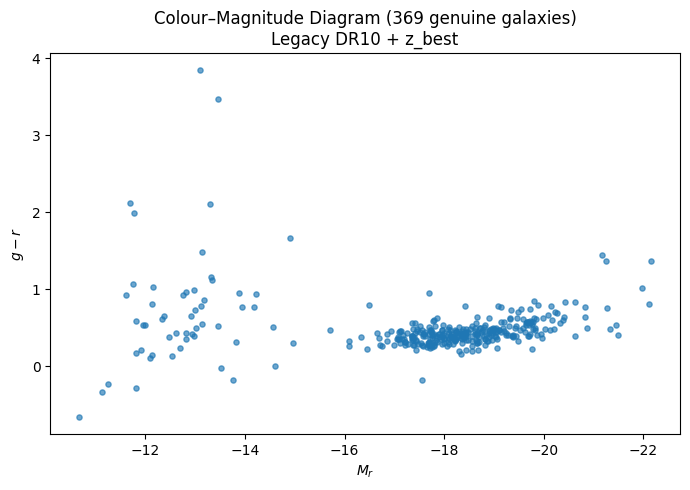

In [32]:
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["pyvo", "astropy", "pandas", "numpy", "matplotlib"]:
    pip_install(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyvo as vo

# ------------------------------------------------------------
# 1) Load your cleaned galaxy master table (369)
# ------------------------------------------------------------
gal = pd.read_csv("GW190814_369_genuine_galaxies_with_specz.csv")
print("Galaxy rows:", len(gal))
print("Spec-z count:", int(gal["has_specz"].sum()) if "has_specz" in gal.columns else "n/a")

# Make sure z_best exists
if "z_best" not in gal.columns:
    raise RuntimeError("z_best column not found. (Should exist in the 369 file.)")

gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

# RA/Dec box (same as your 90% rectangle)
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

# ------------------------------------------------------------
# 2) Query Legacy DR10 tractor for g/r fluxes in this box
#    (fluxes are in nanomaggies)
# ------------------------------------------------------------
svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

adql = f"""
SELECT ra, dec, flux_g, flux_r
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
  AND flux_g > 0
  AND flux_r > 0
"""

print("Querying Legacy DR10 tractor for flux_g/flux_r (may take a bit)...")
leg = svc.search(adql).to_table().to_pandas()
print("Legacy rows in box:", len(leg))

leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

# ------------------------------------------------------------
# 3) Crossmatch 369 galaxies ↔ Legacy sources
# ------------------------------------------------------------
idx, sep, _ = gal_sky.match_to_catalog_sky(leg_sky)
match_radius = 1.0 * u.arcsec
m = sep < match_radius

print("Matches within 1 arcsec:", int(m.sum()), "/", len(gal))

gal_m = gal[m].reset_index(drop=True)
leg_m = leg.iloc[idx[m]].reset_index(drop=True)

merged = pd.concat([gal_m, leg_m[["flux_g","flux_r"]]], axis=1)

# ------------------------------------------------------------
# 4) Compute g, r, g-r, and M_r using z_best
# ------------------------------------------------------------
# Convert nanomaggies → AB mag
merged["g"] = 22.5 - 2.5 * np.log10(merged["flux_g"])
merged["r"] = 22.5 - 2.5 * np.log10(merged["flux_r"])
merged["g_r"] = merged["g"] - merged["r"]

# Absolute M_r via distance modulus using z_best
DL_pc = cosmo.luminosity_distance(merged["z_best"]).to("pc").value
merged["M_r"] = merged["r"] - 5 * np.log10(DL_pc / 10.0)

print("Final CMD sample size:", len(merged))

# ------------------------------------------------------------
# 5) Save CSV of CMD quantities
# ------------------------------------------------------------
cmd_cols = [
    "coadd_object_id", "ra", "dec",
    "dnf_z", "z_ned", "has_specz", "z_best",
    "g", "r", "g_r", "M_r",
    "flux_g", "flux_r"
]
cmd_cols = [c for c in cmd_cols if c in merged.columns]

merged[cmd_cols].to_csv("GW190814_CMD_369_zbest.csv", index=False)
print("Saved: GW190814_CMD_369_zbest.csv")

# ------------------------------------------------------------
# 6) Plot CMD
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(merged["M_r"], merged["g_r"], s=14, alpha=0.65)
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g-r$")
plt.title("Colour–Magnitude Diagram (369 genuine galaxies)\nLegacy DR10 + z_best")
plt.tight_layout()
plt.show()

In [33]:
spec = gal[gal["has_specz"] == True].copy()
print("Spec-z galaxies:", len(spec))

Spec-z galaxies: 65


In [34]:
print(gal.columns.tolist())

['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z', 'gaia_match', 'gaia_sep_arcsec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'phot_g_mean_mag', 'parallax_snr', 'pm_tot', 'pm_tot_err', 'pm_snr', 'gaia_star_veto', 'z_ned', 'ned_name', 'ned_type', 'ned_sep_arcsec', 'ned_radius_used_arcsec', 'has_specz', 'z_best']


In [35]:
!pip -q install pyvo astropy pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

In [36]:
GAL_FILE = "GW190814_369_genuine_galaxies_with_specz.csv"
gal = pd.read_csv(GAL_FILE)

print("Galaxy rows:", len(gal))
print("Spec-z count:", int(gal["has_specz"].sum()) if "has_specz" in gal.columns else "n/a")

# Basic sanity
required = {"coadd_object_id","ra","dec","z_best"}
missing = required - set(gal.columns)
if missing:
    raise ValueError(f"Missing required columns in {GAL_FILE}: {missing}")

gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

Galaxy rows: 369
Spec-z count: 65


In [37]:
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

adql = f"""
SELECT ra, dec, flux_g, flux_r
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
  AND flux_g > 0
  AND flux_r > 0
"""

print("Querying Legacy DR10 tractor (flux_g, flux_r) in patch…")
leg = svc.search(adql).to_table().to_pandas()
print("Legacy rows returned:", len(leg))

leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

Querying Legacy DR10 tractor (flux_g, flux_r) in patch…
Legacy rows returned: 4211270


In [38]:
idx, sep2d, _ = gal_sky.match_to_catalog_sky(leg_sky)

match_radius = 1.0 * u.arcsec
m = sep2d < match_radius

print("Matched galaxies within 1 arcsec:", int(m.sum()), "/", len(gal))

gal_m = gal[m].reset_index(drop=True)
leg_m = leg.iloc[idx[m]].reset_index(drop=True)

merged = pd.concat([gal_m, leg_m[["flux_g","flux_r"]]], axis=1)
merged["legacy_sep_arcsec"] = sep2d[m].to(u.arcsec).value

print("Merged rows:", len(merged))

Matched galaxies within 1 arcsec: 358 / 369
Merged rows: 358


In [39]:
# Convert nanomaggies -> AB mag
merged["g"] = 22.5 - 2.5 * np.log10(merged["flux_g"])
merged["r"] = 22.5 - 2.5 * np.log10(merged["flux_r"])
merged["g_r"] = merged["g"] - merged["r"]

# Absolute Mr using z_best
DL_pc = cosmo.luminosity_distance(merged["z_best"]).to("pc").value
merged["Mr"] = merged["r"] - 5 * np.log10(DL_pc / 10.0)

print(merged[["g","r","g_r","Mr"]].describe())

                g           r         g_r          Mr
count  358.000000  358.000000  358.000000  358.000000
mean    19.733187   19.242970    0.490216  -17.671674
std      2.344132    2.268644    0.364182    2.313173
min     15.766381   14.753913   -0.658066  -22.160561
25%     18.367284   17.935680    0.352487  -19.030918
50%     19.146338   18.755451    0.426624  -18.193509
75%     19.857817   19.450956    0.528627  -17.357871
max     27.995285   26.524918    3.838680  -10.659988


In [40]:
OUT_CMD = "GW190814_CMD_369_with_legacy_photometry.csv"

cols = [
    "coadd_object_id","ra","dec","dnf_z","z_ned","has_specz","z_best",
    "flux_g","flux_r","g","r","g_r","Mr","legacy_sep_arcsec"
]
cols = [c for c in cols if c in merged.columns]

merged[cols].to_csv(OUT_CMD, index=False)
print("Saved:", OUT_CMD)

Saved: GW190814_CMD_369_with_legacy_photometry.csv


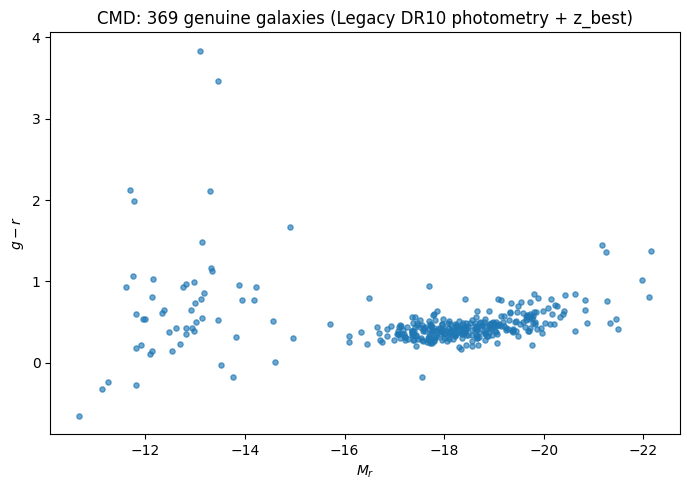

In [41]:
plt.figure(figsize=(7,5))
plt.scatter(merged["Mr"], merged["g_r"], s=14, alpha=0.65)
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: 369 genuine galaxies (Legacy DR10 photometry + z_best)")
plt.tight_layout()
plt.show()

Spec-z CMD sample: 65


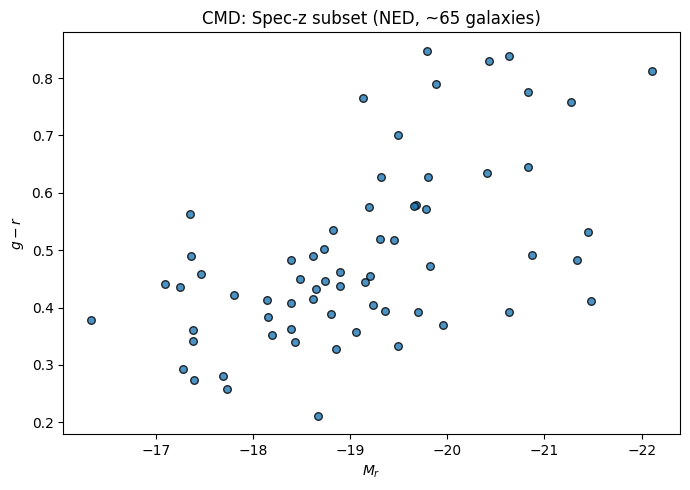

In [42]:
spec = merged[merged["has_specz"] == True].copy()
print("Spec-z CMD sample:", len(spec))

plt.figure(figsize=(7,5))
plt.scatter(spec["Mr"], spec["g_r"], s=30, alpha=0.8, edgecolor="k")
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: Spec-z subset (NED, ~65 galaxies)")
plt.tight_layout()
plt.show()

Spec-z CMD sample: 65


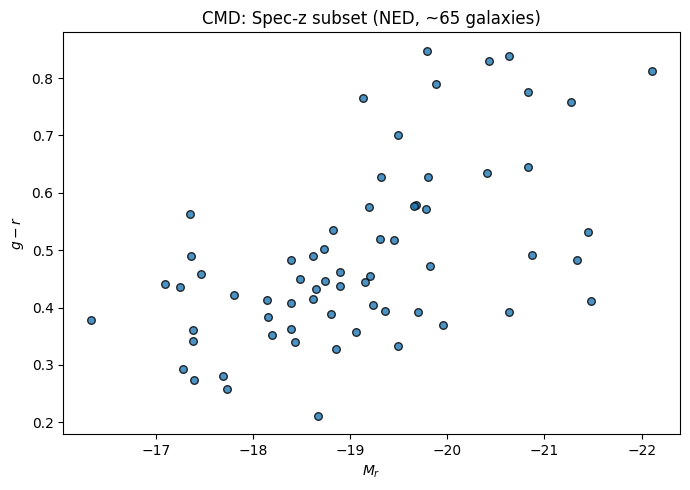

In [43]:
spec = merged[merged["has_specz"] == True].copy()
print("Spec-z CMD sample:", len(spec))

plt.figure(figsize=(7,5))
plt.scatter(spec["Mr"], spec["g_r"], s=30, alpha=0.8, edgecolor="k")
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: Spec-z subset (NED, ~65 galaxies)")
plt.tight_layout()
plt.show()

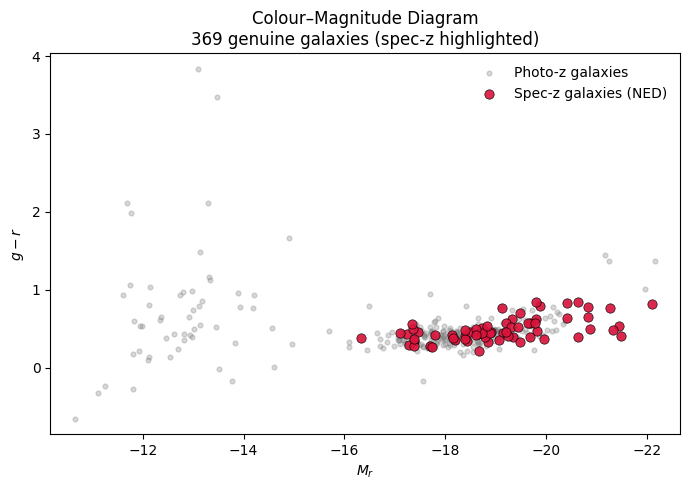

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Background: all genuine galaxies
plt.scatter(
    merged["Mr"], merged["g_r"],
    s=12,
    alpha=0.3,
    color="gray",
    label="Photo-z galaxies"
)

# Foreground: spectroscopic subset
plt.scatter(
    spec["Mr"], spec["g_r"],
    s=45,
    alpha=0.9,
    color="crimson",
    edgecolor="black",
    linewidth=0.5,
    label="Spec-z galaxies (NED)"
)

# Fix axes using full sample
Mr_min, Mr_max = merged["Mr"].min(), merged["Mr"].max()
gr_min, gr_max = merged["g_r"].min(), merged["g_r"].max()

plt.xlim(Mr_max + 0.5, Mr_min - 0.5)  # inverted x-axis
plt.ylim(gr_min - 0.2, gr_max + 0.2)

plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("Colour–Magnitude Diagram\n369 genuine galaxies (spec-z highlighted)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [45]:
import pyvo as vo
import pandas as pd

svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

cols = svc.search("""
SELECT column_name
FROM TAP_SCHEMA.columns
WHERE table_name = 'ls_dr10.tractor'
""").to_table().to_pandas()["column_name"].tolist()

# Show likely size-related columns
cands = [c for c in cols if any(k in c.lower() for k in ["shape", "radius", "rhalf", "r50", "r90", "fracdev"])]
print("Candidate size-ish columns in ls_dr10.tractor:")
print(cands[:80])

Candidate size-ish columns in ls_dr10.tractor:
['shape_r', 'shape_r_ivar', 'shape_e1', 'shape_e1_ivar', 'shape_e2', 'shape_e2_ivar']


Loaded CMD rows: 358
Columns: ['coadd_object_id', 'ra', 'dec', 'dnf_z', 'z_ned', 'has_specz', 'z_best', 'g', 'r', 'g_r', 'M_r', 'flux_g', 'flux_r']
Using M_r as Mr.
Spec-z count: 65
Querying Legacy DR10 for flux_r + shape_r ...
Legacy rows returned: 4297850
Matches within 1 arcsec: 358 / 358


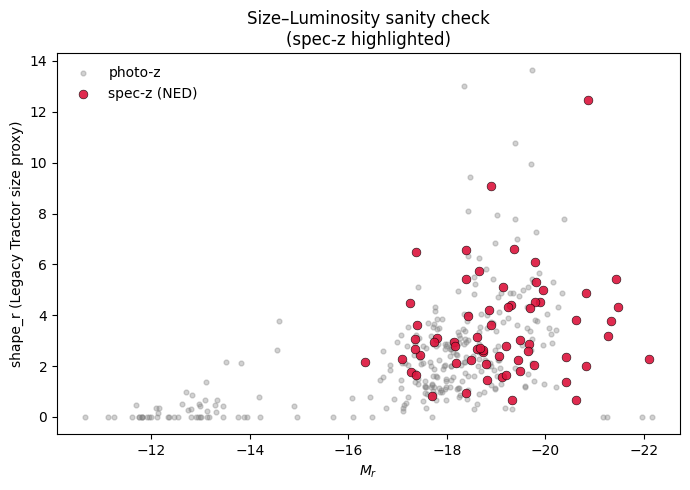

Tiny threshold (10th percentile shape_r among spec-z): 1.5959480285644532
Suspects (Mr > -16 AND very small): 51
Saved merged table: GW190814_CMD_369_zbest_with_shape.csv
Saved suspects table: GW190814_size_luminosity_suspects.csv
 coadd_object_id         Mr  shape_r  shape_r_err   z_best  has_specz  legacy_sep_arcsec
      1099791389 -15.696412 0.000000          NaN 0.059911      False           0.337797
      1124804483 -14.953776 0.000000          NaN 0.049711      False           0.002264
      1117697458 -14.901279 0.438604     0.004838 0.053798      False           0.178957
      1093343186 -14.214204 0.000000          NaN 0.054770      False           0.025633
      1113354021 -14.184040 0.781469     0.015539 0.046050      False           0.081510
      1102170253 -13.937717 0.000000          NaN 0.043320      False           0.167014
      1102168345 -13.884428 0.000000          NaN 0.059540      False           0.170955
      1091782447 -13.762723 0.000000          NaN 0.04352

In [46]:
# ============================================================
# Step 0B MVP: Size–Luminosity sanity check for GW190814 galaxies
# Uses existing CMD file + adds Legacy shape_r
# Robust to Mr vs M_r column naming
# ============================================================

import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["pyvo", "astropy", "pandas", "numpy", "matplotlib"]:
    pip_install(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo
from astropy.coordinates import SkyCoord
import astropy.units as u

# ----------------------------
# CONFIG
# ----------------------------
CMD_FILE = "GW190814_CMD_369_zbest.csv"
OUT_MERGED = "GW190814_CMD_369_zbest_with_shape.csv"
OUT_SUSPECTS = "GW190814_size_luminosity_suspects.csv"

ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

match_radius = 1.0 * u.arcsec

# ----------------------------
# 1) Load CMD file
# ----------------------------
gal = pd.read_csv(CMD_FILE)
print("Loaded CMD rows:", len(gal))
print("Columns:", gal.columns.tolist())

# Handle Mr vs M_r naming
if "Mr" not in gal.columns:
    if "M_r" in gal.columns:
        gal["Mr"] = gal["M_r"]
        print("Using M_r as Mr.")
    else:
        raise ValueError(f"{CMD_FILE} has neither 'Mr' nor 'M_r' column. Columns are: {gal.columns.tolist()}")

# Basic required columns
required = {"coadd_object_id","ra","dec","Mr","has_specz","z_best"}
missing = required - set(gal.columns)
if missing:
    raise ValueError(f"{CMD_FILE} is missing required columns: {missing}")

gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")
print("Spec-z count:", int(gal["has_specz"].sum()))

# ----------------------------
# 2) Query Legacy DR10 for size proxy
# ----------------------------
svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

adql = f"""
SELECT ra, dec, flux_r, shape_r, shape_r_ivar
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
  AND flux_r > 0
  AND shape_r IS NOT NULL
"""

print("Querying Legacy DR10 for flux_r + shape_r ...")
leg = svc.search(adql).to_table().to_pandas()
print("Legacy rows returned:", len(leg))

leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

# ----------------------------
# 3) Crossmatch CMD galaxies -> Legacy
# ----------------------------
idx, sep2d, _ = gal_sky.match_to_catalog_sky(leg_sky)
m = sep2d < match_radius
print("Matches within 1 arcsec:", int(m.sum()), "/", len(gal))

g = gal[m].reset_index(drop=True)
l = leg.iloc[idx[m]].reset_index(drop=True)

# Rename Legacy columns to avoid collisions
l = l.rename(columns={
    "flux_r": "flux_r_leg",
    "shape_r": "shape_r",
    "shape_r_ivar": "shape_r_ivar"
})

df = pd.concat([g, l[["flux_r_leg","shape_r","shape_r_ivar"]]], axis=1)
df["legacy_sep_arcsec"] = sep2d[m].to(u.arcsec).value

# shape_r uncertainty estimate
df["shape_r_err"] = np.where(df["shape_r_ivar"] > 0, 1/np.sqrt(df["shape_r_ivar"]), np.nan)

# ----------------------------
# 4) Plot size–luminosity with spec-z highlighted
# ----------------------------
spec = df[df["has_specz"] == True]
phot = df[df["has_specz"] == False]

plt.figure(figsize=(7,5))
plt.scatter(phot["Mr"], phot["shape_r"], s=12, alpha=0.35, color="gray", label="photo-z")
plt.scatter(spec["Mr"], spec["shape_r"], s=40, alpha=0.9, color="crimson",
            edgecolor="k", linewidth=0.4, label="spec-z (NED)")
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel("shape_r (Legacy Tractor size proxy)")
plt.title("Size–Luminosity sanity check\n(spec-z highlighted)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ----------------------------
# 5) MVP “suspect” flag: tiny + faint
# ----------------------------
tiny_thr = np.nanpercentile(spec["shape_r"], 10)
suspects = df[(df["Mr"] > -16) & (df["shape_r"] < tiny_thr)].copy()

print("Tiny threshold (10th percentile shape_r among spec-z):", tiny_thr)
print("Suspects (Mr > -16 AND very small):", len(suspects))

# Save merged + suspects
df.to_csv(OUT_MERGED, index=False)
suspects.to_csv(OUT_SUSPECTS, index=False)

print("Saved merged table:", OUT_MERGED)
print("Saved suspects table:", OUT_SUSPECTS)

show_cols = ["coadd_object_id","Mr","shape_r","shape_r_err","z_best","has_specz","legacy_sep_arcsec"]
print(suspects[show_cols].sort_values(["Mr","shape_r"]).head(20).to_string(index=False))

In [47]:
import numpy as np

def exclusion_stats(thr):
    total_excl = int((df["shape_r"] < thr).sum())
    total = len(df)

    # spec-z subset
    spec = df[df["has_specz"] == True]
    spec_excl = int((spec["shape_r"] < thr).sum())
    spec_total = len(spec)

    # photo-z subset
    phot = df[df["has_specz"] == False]
    phot_excl = int((phot["shape_r"] < thr).sum())
    phot_total = len(phot)

    return {
        "threshold_arcsec": thr,
        "excluded_total": total_excl,
        "excluded_total_pct": 100*total_excl/total if total else 0,
        "excluded_specz": spec_excl,
        "excluded_specz_pct": 100*spec_excl/spec_total if spec_total else 0,
        "excluded_photoz": phot_excl,
        "excluded_photoz_pct": 100*phot_excl/phot_total if phot_total else 0,
    }

for thr in [0.3, 0.5]:
    print(exclusion_stats(thr))

{'threshold_arcsec': 0.3, 'excluded_total': 43, 'excluded_total_pct': 12.011173184357542, 'excluded_specz': 0, 'excluded_specz_pct': 0.0, 'excluded_photoz': 43, 'excluded_photoz_pct': 14.675767918088738}
{'threshold_arcsec': 0.5, 'excluded_total': 58, 'excluded_total_pct': 16.201117318435752, 'excluded_specz': 0, 'excluded_specz_pct': 0.0, 'excluded_photoz': 58, 'excluded_photoz_pct': 19.795221843003414}


CMD rows loaded: 358
shape_r not in CMD file; attaching from Legacy DR10...
Legacy rows returned: 4319398
CMD rows with shape_r available: 358
shape_r summary:
 count    358.000000
mean       2.507211
std        2.132699
min        0.000000
25%        1.041928
50%        2.168576
75%        3.448339
max       13.624000
Name: shape_r, dtype: float64
Applied shape_r >= 0.3: kept 315/358, removed 43
Spec-z points: 65  Photo-z points: 250


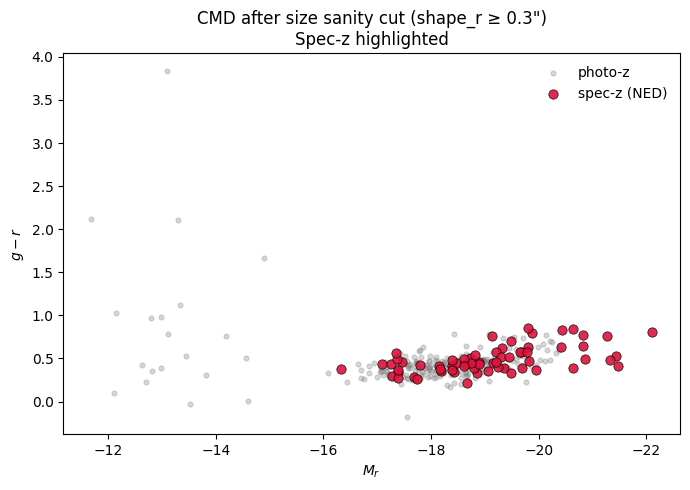

Saved GW190814_CMD_369_zbest_shape_ge_0.3.csv


In [48]:
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["pyvo", "astropy", "pandas", "numpy", "matplotlib"]:
    pip_install(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo
from astropy.coordinates import SkyCoord
import astropy.units as u

CMD_FILE = "GW190814_CMD_369_zbest.csv"  # adjust if needed
SHAPE_CUT = 0.3

# Load CMD table (should have Mr, g_r, has_specz, ra, dec)
cmd = pd.read_csv(CMD_FILE)
print("CMD rows loaded:", len(cmd))
need = {"coadd_object_id","ra","dec","M_r","g_r","has_specz"}
missing = need - set(cmd.columns)
if missing:
    raise ValueError(f"{CMD_FILE} missing columns: {missing}")

# If shape_r already present, use it. Otherwise attach via Legacy match.
if "shape_r" not in cmd.columns:
    print("shape_r not in CMD file; attaching from Legacy DR10...")

    ra_min, ra_max = 10.2392578125, 14.8974609375
    dec_min, dec_max = -27.3215904756, -22.2256480484

    svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")
    adql = f"""
    SELECT ra, dec, shape_r
    FROM ls_dr10.tractor
    WHERE ra BETWEEN {ra_min} AND {ra_max}
      AND dec BETWEEN {dec_min} AND {dec_max}
      AND shape_r IS NOT NULL
    """
    leg = svc.search(adql).to_table().to_pandas()
    print("Legacy rows returned:", len(leg))

    cmd_sky = SkyCoord(cmd["ra"].values*u.deg, cmd["dec"].values*u.deg, frame="icrs")
    leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

    idx, sep2d, _ = cmd_sky.match_to_catalog_sky(leg_sky)
    m = sep2d < (1.0 * u.arcsec)

    cmd = cmd[m].reset_index(drop=True)
    leg_m = leg.iloc[idx[m]].reset_index(drop=True)

    cmd["shape_r"] = pd.to_numeric(leg_m["shape_r"], errors="coerce")
    cmd["legacy_shape_sep_arcsec"] = sep2d[m].to(u.arcsec).value

print("CMD rows with shape_r available:", len(cmd))
print("shape_r summary:\n", cmd["shape_r"].describe())

# Apply size cut
before = len(cmd)
cmd2 = cmd[cmd["shape_r"] >= SHAPE_CUT].copy()
after = len(cmd2)
print(f"Applied shape_r >= {SHAPE_CUT}: kept {after}/{before}, removed {before-after}")

# Split spec vs photo
spec = cmd2[cmd2["has_specz"] == True]
phot = cmd2[cmd2["has_specz"] == False]
print("Spec-z points:", len(spec), " Photo-z points:", len(phot))

# Plot (same style as your earlier overlay)
plt.figure(figsize=(7,5))
plt.scatter(phot["M_r"], phot["g_r"], s=12, alpha=0.3, color="gray", label="photo-z")
plt.scatter(spec["M_r"], spec["g_r"], s=45, alpha=0.9, color="crimson",
            edgecolor="black", linewidth=0.5, label="spec-z (NED)")

plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title(f"CMD after size sanity cut (shape_r ≥ {SHAPE_CUT}\")\nSpec-z highlighted")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Save the filtered CMD table too (handy for Mark)
cmd2.to_csv(f"GW190814_CMD_369_zbest_shape_ge_{SHAPE_CUT}.csv", index=False)
print(f"Saved GW190814_CMD_369_zbest_shape_ge_{SHAPE_CUT}.csv")

Excluded (shape_r < 0.3): 43
Kept (shape_r >= 0.3): 315


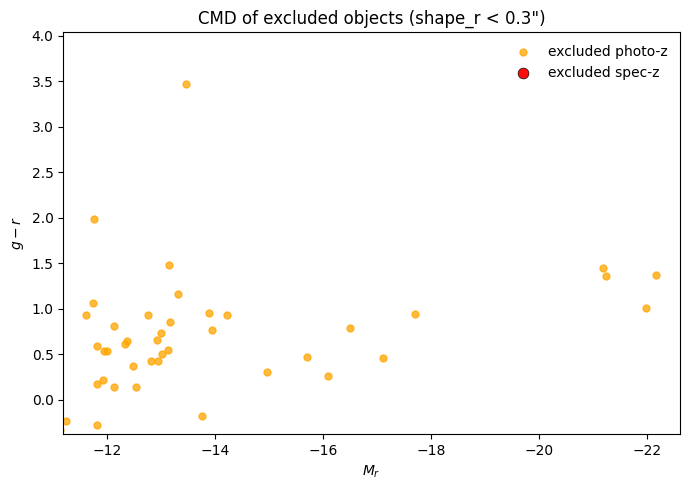

Saved GW190814_CMD_excluded_shape_lt_0.3.csv


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyvo as vo

CMD_FILE = "GW190814_CMD_369_zbest.csv"
SHAPE_CUT = 0.3

# --- Load CMD file ---
cmd = pd.read_csv(CMD_FILE)

need = {"coadd_object_id","ra","dec","M_r","g_r","has_specz"}
missing = need - set(cmd.columns)
if missing:
    raise ValueError(f"{CMD_FILE} missing columns: {missing}")

# --- Attach shape_r if needed ---
if "shape_r" not in cmd.columns:
    ra_min, ra_max = 10.2392578125, 14.8974609375
    dec_min, dec_max = -27.3215904756, -22.2256480484

    svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")
    adql = f"""
    SELECT ra, dec, shape_r
    FROM ls_dr10.tractor
    WHERE ra BETWEEN {ra_min} AND {ra_max}
      AND dec BETWEEN {dec_min} AND {dec_max}
      AND shape_r IS NOT NULL
    """
    leg = svc.search(adql).to_table().to_pandas()

    cmd_sky = SkyCoord(cmd["ra"].values*u.deg, cmd["dec"].values*u.deg, frame="icrs")
    leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

    idx, sep2d, _ = cmd_sky.match_to_catalog_sky(leg_sky)
    m = sep2d < (1.0 * u.arcsec)

    cmd = cmd[m].reset_index(drop=True)
    cmd["shape_r"] = pd.to_numeric(leg.iloc[idx[m]]["shape_r"].values, errors="coerce")

# --- Split kept vs excluded ---
excluded = cmd[cmd["shape_r"] < SHAPE_CUT].copy()
kept     = cmd[cmd["shape_r"] >= SHAPE_CUT].copy()

print(f"Excluded (shape_r < {SHAPE_CUT}):", len(excluded))
print(f"Kept (shape_r >= {SHAPE_CUT}):", len(kept))

# --- Use common axes based on the kept sample (so it's comparable) ---
Mr_min, Mr_max = kept["M_r"].min(), kept["M_r"].max()
gr_min, gr_max = kept["g_r"].min(), kept["g_r"].max()

Mr_lim = (Mr_max + 0.5, Mr_min - 0.5)  # inverted
gr_lim = (gr_min - 0.2, gr_max + 0.2)

# --- Plot excluded CMD (spec-z highlighted, though you expect none) ---
spec_ex = excluded[excluded["has_specz"] == True]
phot_ex = excluded[excluded["has_specz"] == False]

plt.figure(figsize=(7,5))
plt.scatter(phot_ex["M_r"], phot_ex["g_r"], s=25, alpha=0.75, color="orange", label="excluded photo-z")
plt.scatter(spec_ex["M_r"], spec_ex["g_r"], s=60, alpha=0.95, color="red",
            edgecolor="black", linewidth=0.5, label="excluded spec-z")

plt.xlim(Mr_lim)
plt.ylim(gr_lim)
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title(f"CMD of excluded objects (shape_r < {SHAPE_CUT}\")")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Save excluded list for auditing ---
excluded.to_csv(f"GW190814_CMD_excluded_shape_lt_{SHAPE_CUT}.csv", index=False)
print(f"Saved GW190814_CMD_excluded_shape_lt_{SHAPE_CUT}.csv")

In [50]:
# cmd2 is the CMD table AFTER shape_r >= 0.3 cut

total_kept = len(cmd2)
faint = cmd2[cmd2["M_r"] > -16]
bright = cmd2[cmd2["M_r"] <= -16]

print("Total galaxies after size cut:", total_kept)
print("Faint galaxies (Mr > -16):", len(faint))
print("Bright galaxies (Mr <= -16):", len(bright))
print("Fraction faint:", len(faint) / total_kept)

# Optional: break down faint by spec-z vs photo-z
print("\nFaint galaxies breakdown:")
print(faint["has_specz"].value_counts())

Total galaxies after size cut: 315
Faint galaxies (Mr > -16): 20
Bright galaxies (Mr <= -16): 295
Fraction faint: 0.06349206349206349

Faint galaxies breakdown:
has_specz
False    20
Name: count, dtype: int64


In [51]:
# Focus on the faint tail
faint = cmd2[cmd2["M_r"] > -16].copy()
print("Faint tail size (M_r > -16):", len(faint))

# Summary of apparent r magnitudes
print("\nApparent r-band magnitude summary:")
print(faint["r"].describe())

# Count how many are very faint in apparent terms
too_faint = faint[faint["r"] > 23]
ok_faint = faint[faint["r"] <= 23]

print("\nFaint tail with r > 23:", len(too_faint))
print("Faint tail with r <= 23:", len(ok_faint))

# Inspect the problematic ones
cols = ["coadd_object_id","r","M_r","g_r","shape_r","has_specz","z_best"]
print("\nObjects with M_r > -16 and r > 23:")
print(too_faint[cols].sort_values("r").to_string(index=False))

# Optional: save for record
too_faint.to_csv("GW190814_faint_tail_r_gt_23.csv", index=False)

Faint tail size (M_r > -16): 20

Apparent r-band magnitude summary:
count    20.000000
mean     23.686287
std       0.854792
min      22.026928
25%      23.425659
50%      23.875684
75%      24.157858
max      25.360245
Name: r, dtype: float64

Faint tail with r > 23: 16
Faint tail with r <= 23: 4

Objects with M_r > -16 and r > 23:
 coadd_object_id         r        M_r       g_r  shape_r  has_specz   z_best
      1114898790 23.341917 -13.823045  0.312981 2.132707      False 0.058590
      1114899539 23.453573 -13.111408  0.788237 1.367756      False 0.044880
      1114903407 23.554356 -13.453360  0.526447 0.433073      False 0.054649
      1117702793 23.605950 -13.516868 -0.025309 2.170114      False 0.057507
      1105060630 23.792572 -13.292033  2.110605 0.477092      False 0.056543
      1102186147 23.872026 -13.340169  1.121557 0.666255      False 0.059826
      1107599832 23.879343 -12.822109  0.351818 0.861560      False 0.047695
      1095497057 23.920360 -12.983913  0.391045 0

In [52]:
import os
import time
import requests
from PIL import Image, ImageDraw, ImageFont
from math import ceil

# -----------------------
# CONFIG
# -----------------------
OUT_DIR = "cutouts_faint_tail_20"
LAYER = "ls-dr10"
SIZE = 384   # 256 is fine; 384 makes inspection easier
COLS = 5      # 4x5 or 5x4 both fine

# -----------------------
# Sanity checks
# -----------------------
if "faint" not in globals():
    raise NameError("Variable 'faint' not found. Make sure you have created faint = ... before running this cell.")

need_cols = {"coadd_object_id", "ra", "dec"}
missing = need_cols - set(faint.columns)
if missing:
    raise ValueError(f"'faint' is missing required columns: {missing}. Columns are: {faint.columns.tolist()}")

print("Rows in faint:", len(faint))

# Keep stable order if possible
if "r" in faint.columns:
    faint2 = faint.sort_values("r").copy()
elif "Mr" in faint.columns:
    faint2 = faint.sort_values("Mr").copy()
else:
    faint2 = faint.copy()

ids = faint2["coadd_object_id"].astype(int).tolist()
print("\nFaint-tail IDs:")
print(ids)

# -----------------------
# Download cutouts
# -----------------------
os.makedirs(OUT_DIR, exist_ok=True)

def fetch_cutout(ra, dec, obj_id):
    url = (
        "https://www.legacysurvey.org/viewer/cutout.jpg"
        f"?ra={ra}&dec={dec}&layer={LAYER}&width={SIZE}&height={SIZE}"
    )
    r = requests.get(url, timeout=25)
    r.raise_for_status()
    ctype = r.headers.get("Content-Type","")
    if not ctype.startswith("image/jpeg"):
        raise RuntimeError(f"Non-JPEG response for {obj_id}: {ctype}")
    path = os.path.join(OUT_DIR, f"{obj_id}.jpg")
    with open(path, "wb") as f:
        f.write(r.content)
    return path

paths = []
failed = []

for _, row in faint2.iterrows():
    obj_id = int(row["coadd_object_id"])
    ra = float(row["ra"])
    dec = float(row["dec"])
    try:
        p = fetch_cutout(ra, dec, obj_id)
        paths.append((obj_id, p))
        print("Downloaded", obj_id)
    except Exception as e:
        print("FAILED", obj_id, e)
        failed.append(obj_id)
    time.sleep(0.2)

print("\nDownloaded:", len(paths), "Failed:", len(failed))
if failed:
    print("Failed IDs:", failed)

# -----------------------
# Build contact sheet
# -----------------------
rows = ceil(len(paths) / COLS)
label_h = 26
sheet_w = COLS * SIZE
sheet_h = rows * (SIZE + label_h)

sheet = Image.new("RGB", (sheet_w, sheet_h), "black")
draw = ImageDraw.Draw(sheet)

try:
    font = ImageFont.truetype("arial.ttf", 18)
except:
    font = ImageFont.load_default()

for i, (obj_id, p) in enumerate(paths):
    rr = i // COLS
    cc = i % COLS
    x = cc * SIZE
    y = rr * (SIZE + label_h)

    im = Image.open(p).convert("RGB").resize((SIZE, SIZE))
    sheet.paste(im, (x, y))

    draw.rectangle([x, y+SIZE, x+SIZE, y+SIZE+label_h], fill=(0,0,0))
    draw.text((x+4, y+SIZE+4), str(obj_id), fill="white", font=font)

sheet_path = os.path.join(OUT_DIR, "sheet_faint_tail_20.jpg")
sheet.save(sheet_path)
print("Saved contact sheet:", sheet_path)

Rows in faint: 20

Faint-tail IDs:
[1114903167, 1117697458, 1113354021, 1117137001, 1114898790, 1114899539, 1114903407, 1117702793, 1105060630, 1102186147, 1107599832, 1095497057, 1114900614, 1111978027, 1100713728, 1103572431, 1122261943, 1114903141, 1095677983, 1102928381]
Downloaded 1114903167
Downloaded 1117697458
Downloaded 1113354021
Downloaded 1117137001
Downloaded 1114898790
Downloaded 1114899539
Downloaded 1114903407
Downloaded 1117702793
Downloaded 1105060630
Downloaded 1102186147
Downloaded 1107599832
Downloaded 1095497057
Downloaded 1114900614
Downloaded 1111978027
Downloaded 1100713728
Downloaded 1103572431
Downloaded 1122261943
Downloaded 1114903141
Downloaded 1095677983
Downloaded 1102928381

Downloaded: 20 Failed: 0
Saved contact sheet: cutouts_faint_tail_20/sheet_faint_tail_20.jpg


Loaded rows: 358
Excluding IDs from in-memory `faint` variable: 20
Excluded 20 galaxies (faint tail). Remaining: 338

Counts after faint-tail exclusion:
Total galaxies: 338
With spec-z: 65
Without spec-z: 273


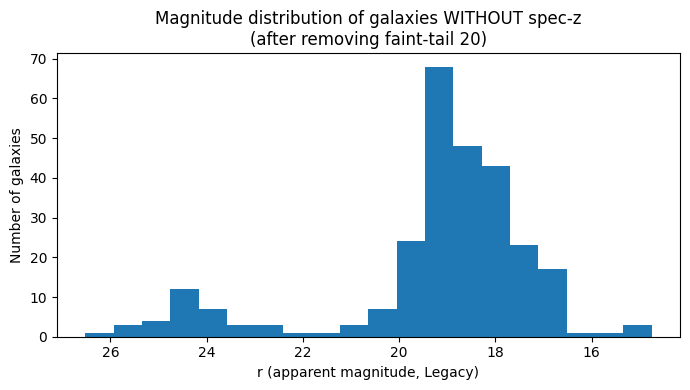


Saved filtered CMD table: GW190814_CMD_filtered_no_faint20.csv


In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
# -----------------------
CMD_FILE = "GW190814_CMD_369_zbest_with_shape.csv"  # <-- change if your latest CMD table has a different name
FAINT_CUTOUT_DIR = "GW190814_faint_tail_r_gt_23.csv"         # where you downloaded the 20 images

# -----------------------
# 1) Load CMD / sample table
# -----------------------
df = pd.read_csv(CMD_FILE)

required = {"coadd_object_id", "has_specz", "r"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"{CMD_FILE} is missing columns {missing}. Columns are: {df.columns.tolist()}")

print("Loaded rows:", len(df))

# -----------------------
# 2) Identify the 20 faint-tail IDs to exclude
#    Priority order:
#    (A) use the in-memory variable `faint` if it exists
#    (B) else infer from downloaded cutout filenames
# -----------------------
exclude_ids = set()

# (A) from variable `faint` if present
if "faint" in globals():
    if {"coadd_object_id"}.issubset(faint.columns):
        exclude_ids = set(faint["coadd_object_id"].astype(int).tolist())
        print("Excluding IDs from in-memory `faint` variable:", len(exclude_ids))
    else:
        print("Found `faint` variable, but it lacks coadd_object_id column. Ignoring.")

# (B) otherwise from cutout directory filenames
if len(exclude_ids) == 0:
    if os.path.isdir(FAINT_CUTOUT_DIR):
        jpgs = [f for f in os.listdir(FAINT_CUTOUT_DIR) if f.lower().endswith(".jpg")]
        # Ignore the sheet file if present
        jpgs = [f for f in jpgs if not f.lower().startswith("sheet")]
        exclude_ids = set(int(os.path.splitext(f)[0]) for f in jpgs if os.path.splitext(f)[0].isdigit())
        print("Excluding IDs from cutout filenames:", len(exclude_ids))
    else:
        raise FileNotFoundError(
            f"Neither `faint` variable exists nor directory {FAINT_CUTOUT_DIR} found. "
            "Tell me how you want to provide the 20 IDs."
        )

# -----------------------
# 3) Apply exclusion
# -----------------------
before = len(df)
df2 = df[~df["coadd_object_id"].isin(exclude_ids)].copy()
after = len(df2)

print(f"Excluded {before-after} galaxies (faint tail). Remaining:", after)

# -----------------------
# 4) Count how many remaining lack spec-z
# -----------------------
n_total = len(df2)
n_spec  = int(df2["has_specz"].sum())
n_nospec = n_total - n_spec

print("\nCounts after faint-tail exclusion:")
print("Total galaxies:", n_total)
print("With spec-z:", n_spec)
print("Without spec-z:", n_nospec)

# -----------------------
# 5) Plot r-band magnitude distribution for those without spec-z
# -----------------------
nospec = df2[df2["has_specz"] == False].copy()

plt.figure(figsize=(7,4))
plt.hist(nospec["r"].dropna(), bins=20)
plt.gca().invert_xaxis()  # brighter to the left (optional; remove if you prefer normal)
plt.xlabel("r (apparent magnitude, Legacy)")
plt.ylabel("Number of galaxies")
plt.title("Magnitude distribution of galaxies WITHOUT spec-z\n(after removing faint-tail 20)")
plt.tight_layout()
plt.show()

# Optional: save the filtered table for next steps
df2.to_csv("GW190814_CMD_filtered_no_faint20.csv", index=False)
print("\nSaved filtered CMD table: GW190814_CMD_filtered_no_faint20.csv")


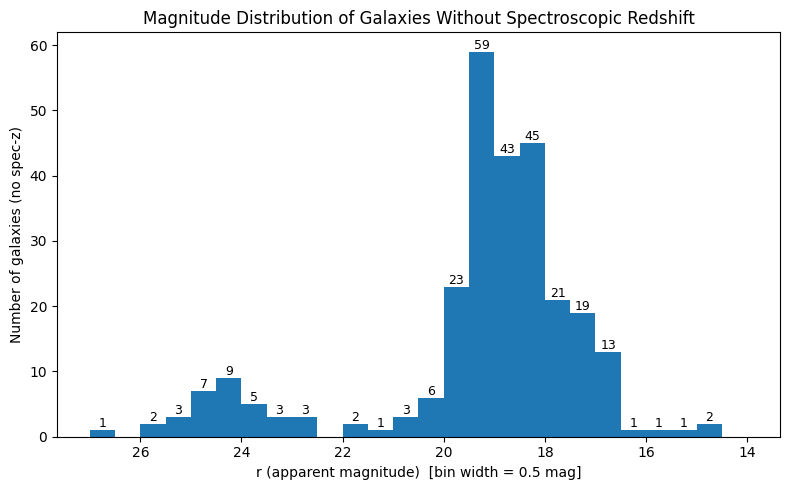

Bin width: 0.5 mag
Magnitude range: 14.0 to 27.0
Total galaxies without spec-z: 273


In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Use filtered dataframe from previous step
# df2 = filtered sample
# nospec = galaxies without spec-z

# -----------------------
# Explicit bin size
# -----------------------
bin_width = 0.5  # <-- change to 0.25 if you want finer bins

r_vals = nospec["r"].dropna().values

r_min = np.floor(r_vals.min())
r_max = np.ceil(r_vals.max())

bins = np.arange(r_min, r_max + bin_width, bin_width)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8,5))

counts, edges, patches = plt.hist(r_vals, bins=bins)

# Label counts above bars
for count, edge_left in zip(counts, edges[:-1]):
    if count > 0:
        plt.text(edge_left + bin_width/2,
                 count,
                 str(int(count)),
                 ha='center',
                 va='bottom',
                 fontsize=9)

plt.gca().invert_xaxis()
plt.xlabel(f"r (apparent magnitude)  [bin width = {bin_width} mag]")
plt.ylabel("Number of galaxies (no spec-z)")
plt.title("Magnitude Distribution of Galaxies Without Spectroscopic Redshift")
plt.tight_layout()
plt.show()

# -----------------------
# Print summary info
# -----------------------
print("Bin width:", bin_width, "mag")
print("Magnitude range:", r_min, "to", r_max)
print("Total galaxies without spec-z:", len(r_vals))

Starting galaxies: 358
After removing faint tail (M_r > -16): 303
Removed: 55


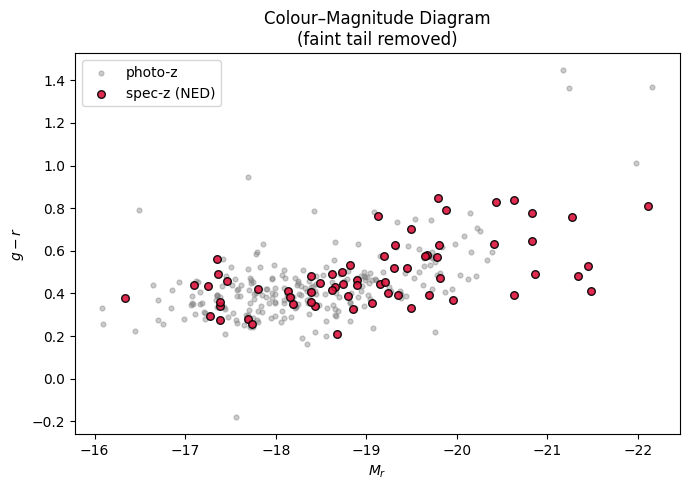

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo

# Load your current genuine galaxy file
gal = pd.read_csv("GW190814_CMD_369_zbest_with_shape.csv")

print("Starting galaxies:", len(gal))

# ------------------------------------------------------------
# Recompute g, r, Mr if not already present
# ------------------------------------------------------------

if "g_r" not in gal.columns or "Mr" not in gal.columns:

    # You must have flux_g and flux_r already merged previously
    if "flux_g" not in gal.columns or "flux_r" not in gal.columns:
        raise ValueError("flux_g / flux_r not present — need Legacy merge step first.")

    gal["g"] = 22.5 - 2.5*np.log10(gal["flux_g"])
    gal["r"] = 22.5 - 2.5*np.log10(gal["flux_r"])

    DL_pc = cosmo.luminosity_distance(gal["z_best"]).to("pc").value
    gal["Mr"] = gal["r"] - 5*np.log10(DL_pc/10.0)
    gal["g_r"] = gal["g"] - gal["r"]

# ------------------------------------------------------------
# Remove faint tail (M_r > -16)
# ------------------------------------------------------------

clean = gal[gal["Mr"] <= -16].copy()

print("After removing faint tail (M_r > -16):", len(clean))
print("Removed:", len(gal) - len(clean))

# ------------------------------------------------------------
# Plot CMD
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

# Photo-z galaxies (grey)
plt.scatter(
    clean.loc[~clean["has_specz"], "Mr"],
    clean.loc[~clean["has_specz"], "g_r"],
    s=12, alpha=0.4, color="grey",
    label="photo-z"
)

# Spec-z galaxies (red)
plt.scatter(
    clean.loc[clean["has_specz"], "Mr"],
    clean.loc[clean["has_specz"], "g_r"],
    s=30, alpha=0.9, color="crimson",
    edgecolor="black",
    label="spec-z (NED)"
)

plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("Colour–Magnitude Diagram\n(faint tail removed)")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
import numpy as np

# df2 should be your table AFTER excluding the faint-tail 20
# If df2 doesn't exist, use Fix B below.
gal_no_spec = df2[df2["has_specz"] == False].copy()

r_vals = gal_no_spec["r"].dropna()
total = len(r_vals)

print(f"Total galaxies without spec-z (after cuts): {total}\n")

for t in [21, 22, 23]:
    bright = np.sum(r_vals < t)
    faint  = np.sum(r_vals >= t)
    print(f"--- r < {t} ---")
    print(f"Brighter than {t}: {bright} ({bright/total*100:.1f}%)")
    print(f"Fainter than {t}:  {faint} ({faint/total*100:.1f}%)\n")

Total galaxies without spec-z (after cuts): 273

--- r < 21 ---
Brighter than 21: 237 (86.8%)
Fainter than 21:  36 (13.2%)

--- r < 22 ---
Brighter than 22: 240 (87.9%)
Fainter than 22:  33 (12.1%)

--- r < 23 ---
Brighter than 23: 243 (89.0%)
Fainter than 23:  30 (11.0%)

